# __Histograms__







## Learning Outcome

In this section, you'll learn to:

- Plot and analyse Image histogram
- Use Histogram equalization to adjust the brightness and contrast of an image


## __Introduction__

__What is Histogram?__

In general histogram is a frequency distribution.

__So what is Image histogram ?__

* A Image histogram is a graph, that gives you the pixel intensity distribution of an image.
Pixel intensity value of 8-bit image ranges form 0-255.

In this entire tutorial I'll use 8-bit grayscale image.

Looking at the histogram of an image, you get an intuition about:

* contrast,
* brightness,
* intensity distribution, etc.  

Therefore It is just another way of understanding the Picture.



## Example


<image>
<center>
<img src="https://drive.google.com/uc?export=view&id=1Uhpowkmyk-Z_edXvZY0J14YF-ab_LxTR" />
<Figcaption>Figure 1: Image and its histogram</Figcaption>
</center>
</image>



In `Figure 1:` you can see Image and its Histogram. It is a 8-bit grayscale Image whose pixel intensity value ranges from $0$ to $2^8 -1 =255 ~~or~~ [0, 255]$.
In the image histogram, you can see:

* Excess dark and light range values along with under-populated mid-tones.
Dark is due to grass and light is due to flower petals.

It means the lighting is low.

Note:

* `0` is `black` color and `255` is `white` color in 8 bit grayscale image.

If we look at the image qualiatively, we can see there are a lot of dark areas. This is due to the leaves and other artifacts. The flower petals on the other hand are bright. This information is presented in the histogram.

_The area where most of the brightness values are present is called the "tonal range." It varies from Image to Image._

## 1. Compute Histogram using OpenCV

From histogram you can find:
* Minimum value of pixel intensity
* Maximum value of pixel intensity
* Average values of pixel intensity



You can use [cv2.calcHist()](https://docs.opencv.org/trunk/d6/dc7/group__imgproc__hist.html#ga4b2b5fd75503ff9e6844cc4dcdaed35d)
function to find the histogram.

     cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])



* images: it is the source image of type uint8 or float32. It should be given in square brackets, i.e., "[img]."

* channels: it is also given in square brackets. It is the index of the channel for which we calculate the histogram. For example, if the input is a grayscale image, its value is [0]. For a color image, you can pass [0], [1], or [2] to calculate a histogram of blue, green, or red channels, respectively.

* mask: mask image. For the histogram of the full image, it is given as "None." But if you want to find a histogram of a particular region of the image, you have to create a mask image and give it as a mask.

* histSize: this represents our BIN count. Need to be given in square brackets. For full scale, we pass [256].

* ranges: this is our RANGE. Normally, it is $\text{[0,256]}$ (for full-grayscale image).

In [1]:
!wget --no-check-certificate 'https://www.publicdomainpictures.net/pictures/20000/velka/bush-roses-117101295939187IVE.jpg' -O flower.PNG

--2025-08-12 13:11:10--  https://www.publicdomainpictures.net/pictures/20000/velka/bush-roses-117101295939187IVE.jpg
Resolving www.publicdomainpictures.net (www.publicdomainpictures.net)... 2606:4700:10::ac42:8c37, 2606:4700:10::ac42:863c, 172.66.134.60, ...
Connecting to www.publicdomainpictures.net (www.publicdomainpictures.net)|2606:4700:10::ac42:8c37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 277649 (271K) [image/jpeg]
Saving to: ‘flower.PNG’

flower.PNG          100%[===================>] 271.14K  --.-KB/s    in 0.01s   

2025-08-12 13:11:11 (21.8 MB/s) - ‘flower.PNG’ saved [277649/277649]



In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('flower.PNG')

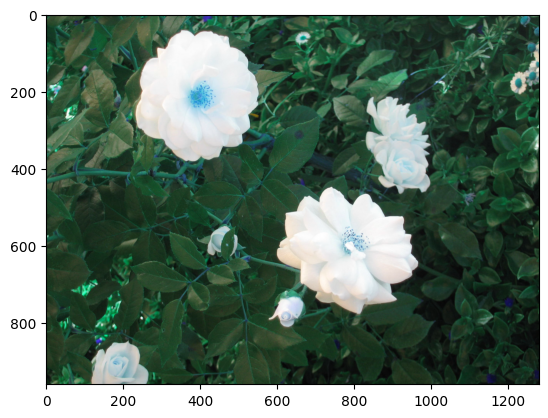

In [3]:
plt.imshow(img, cmap= 'gray')

In [4]:
min_val = 0
max_val = 256

In [5]:
hist = cv2.calcHist([img],[0],None,[256],[min_val,max_val])

To learn more about these parameter click [Here](https://docs.opencv.org/trunk/d1/db7/tutorial_py_histogram_begins.html)

In [6]:
hist.shape # 8 bit channel so 2^8

(256, 1)

_hist is a 256x1 array._
* bins = 256

## What is bins?


8 bit Image contains pixel intensity in the range $\text{[0−255]}.$  If you count how many pixel values does $\text{[0−15]}$ has then it is called bins.  The above output $\text{bins= 256}$ gives range of information value for full scale image histogram. Because you have passed $\text{256}$ as $\text{histSize}$ argument.

* $\text{histSize}$ : It represents BIN count.You should pass it on square brackets. In our example above, we have used a full-scale histogram. Therefore we passed $\text{[256]}$

You can change the $\text{histSize}$ parameter to get different histogram. I will change $\text{histSize}$ and compare different histogram plots.

## 2. Histogram Calculation in Numpy

Numpy also provides you a function, [np.histogram()](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html).

    hist,bins = np.histogram(img.ravel(),256,[0,256])



In [7]:
hist,bins = np.histogram(img.ravel(),max_val,[min_val,max_val])
print(hist.shape)
print(bins.shape)

(256,)
(257,)


bins is 257 why? [Click](https://docs.opencv.org/master/d1/db7/tutorial_py_histogram_begins.html)


__Note:__

* If you want to plot a histogram OpenCV is faster than numpy.

## __Plotting Histograms__

There are two ways for this,

- Using matplotlib
- Using OpenCV




__Matplotlib__

Matplotlib directly finds the histogram and plot it. you donot need  `calcHist() or np.histogram()` function.

__Example__

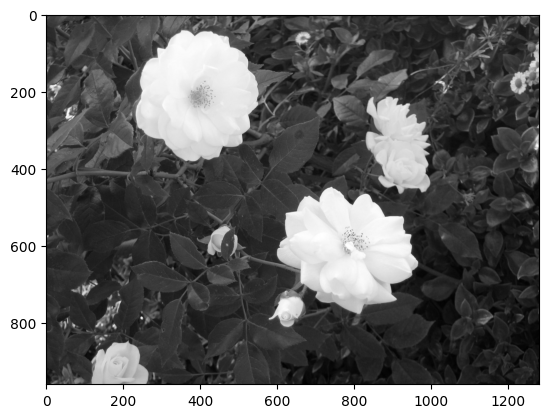

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('flower.PNG',0)
plt.imshow(img,cmap='gray')

/tmp/ipykernel_16821/1515810429.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),max_val,[min_val,max_val],color='blue')


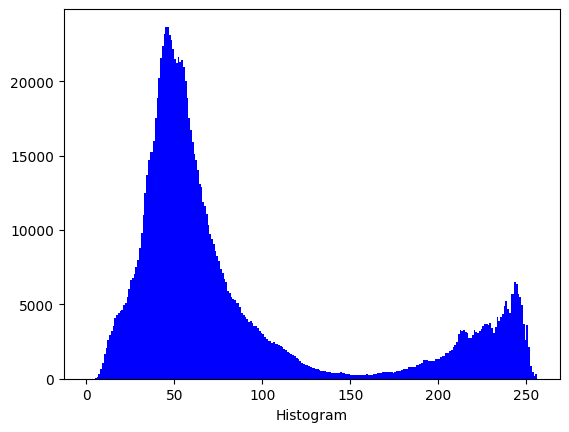

In [9]:
plt.hist(img.ravel(),max_val,[min_val,max_val],color='blue')
plt.xlabel("Histogram")
# plt.savefig('histogram.PNG')
plt.show()

In [10]:
new_image = cv2.convertScaleAbs(img, alpha=2.5, beta=5)

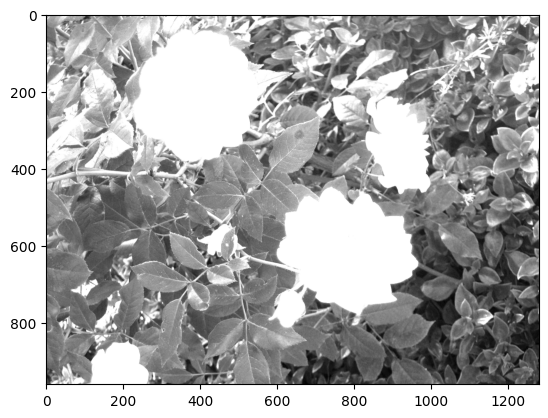

In [11]:
plt.imshow(new_image,cmap='gray')

/tmp/ipykernel_16821/3038912726.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(new_image.ravel(),max_val,[min_val,max_val])


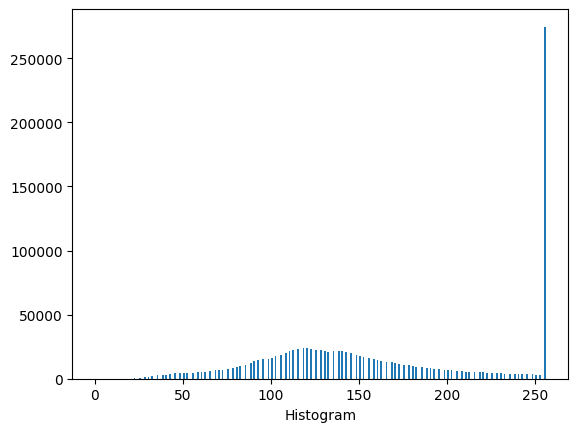

In [12]:
plt.hist(new_image.ravel(),max_val,[min_val,max_val])
plt.xlabel("Histogram")
plt.show()

Now the pixel is densly distributed in range 50-255.

__Using OpenCV__

Use [cv2.calcHist()](https://docs.opencv.org/master/d1/db7/tutorial_py_histogram_begins.html)(in-built function in OpenCV) to find the histogram.

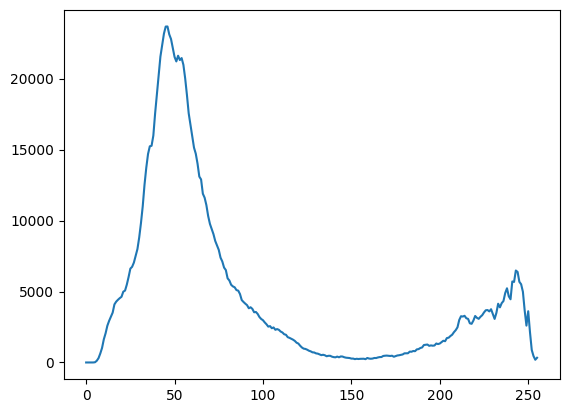

In [13]:
# find frequency of pixels in range 0-255
histr = cv2.calcHist([img],[0],None,[max_val],[min_val,max_val])
# show the plotting graph of an image
plt.plot(histr)
plt.show()

Let's change the $\text{histSize}$ parameter and visulaize the results. I will use:


* $\text{histSize} = 32$
*  $\text{histSize} = 64$
* $\text{histSize} = 150$
* $\text{histSize} = 256$



Calculate the histogram for the given  $\text{histSize}$ parameter.

In [14]:
histogram32  = cv2.calcHist([img],[0],None,[32],[min_val,max_val])
histogram64  = cv2.calcHist([img],[0],None,[64],[min_val,max_val])
histogram150 = cv2.calcHist([img],[0],None,[150],[min_val,max_val])
histr        = cv2.calcHist([img],[0],None,[256],[min_val,max_val])

Plot the results.

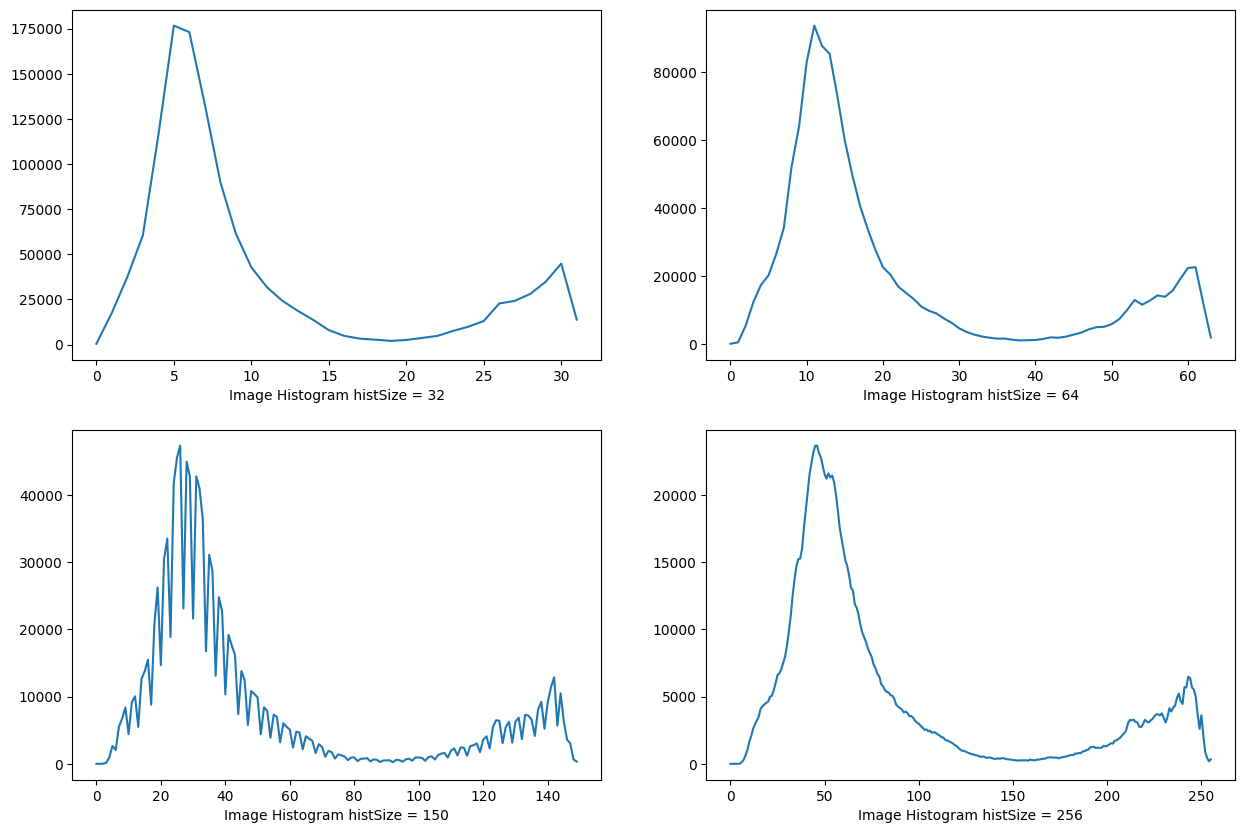

In [15]:
#@title Change in bins
f, axes = plt.subplots(2, 2 , figsize=(15,10))
axes[0,0].plot(histogram32)
axes[0,1].plot(histogram64)
axes[1,0].plot(histogram150)
axes[1,1].plot(histr)
plt.setp(axes[0,0], xlabel='Image Histogram histSize = 32')
plt.setp(axes[0,1], xlabel='Image Histogram histSize = 64')
plt.setp(axes[1,0], xlabel='Image Histogram histSize = 150')
plt.setp(axes[1,1], xlabel='Image Histogram histSize = 256')
# f.tight_layout()
# plt.savefig('binchange.PNG')
plt.show()

Change in $\text{histSize}$ parameter gives different histogram. You can notice the difference on each peak of a histogram and the histogram scale on the x and y-axis.

# __Histogram Equalization__


## __Introduction__


The goal of histogram equalization is to find and apply a point operation such that the histogram of the modified image is flat. Therefore histogram equalization can be used to improve contrast of Image. $ _{[1]}$

* Histogram equalization is a method in image processing of contrast enhancement using the image's histogram.

* Equalization of histograms is the best approach for improving images. It delivers better image quality without any loss of information. $ _{[2]}$


* In Histogram equalization, contrast doesn't always need to increase. There may be some cases were histogram equalization can be worse. In those cases, the contrast decreases.


<image>
<center>

<img src="https://drive.google.com/uc?export=view&id=1D-KKJBopusMZvbrfgpiLxZgoz-usBqK0"/>

<Figcaption>Figure 2: Histogram equalization</Figcaption>

</center>
</image>




`Figure 1` contains excess dark and light values.

What if you can brighten some dark values and darken some light values at the same time while still using the full extent of the available dynamic range?
You can find intensity mapping function $f(I)$ to make resulting histogram flat. This process is called Histogram equalization. $_{[3]}$


__Histograms Equalization in Numpy: [Click](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_histograms/py_histogram_equalization/py_histogram_equalization.html)__

## __Histograms Equalization in OpenCV__

You can use [cv2.equalizeHist(src)](https://docs.opencv.org/master/d5/daf/tutorial_py_histogram_equalization.html) for histogram equalization.

In [16]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('flower.PNG',0)

In [17]:
equ = cv2.equalizeHist(img)

__HIstogram Plot__



/tmp/ipykernel_16821/4200831297.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1,0].hist(img.flatten(),max_val,[min_val,max_val], color = 'blue')
/tmp/ipykernel_16821/4200831297.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1,1].hist(equ.flatten(),max_val,[min_val,max_val], color = 'blue')


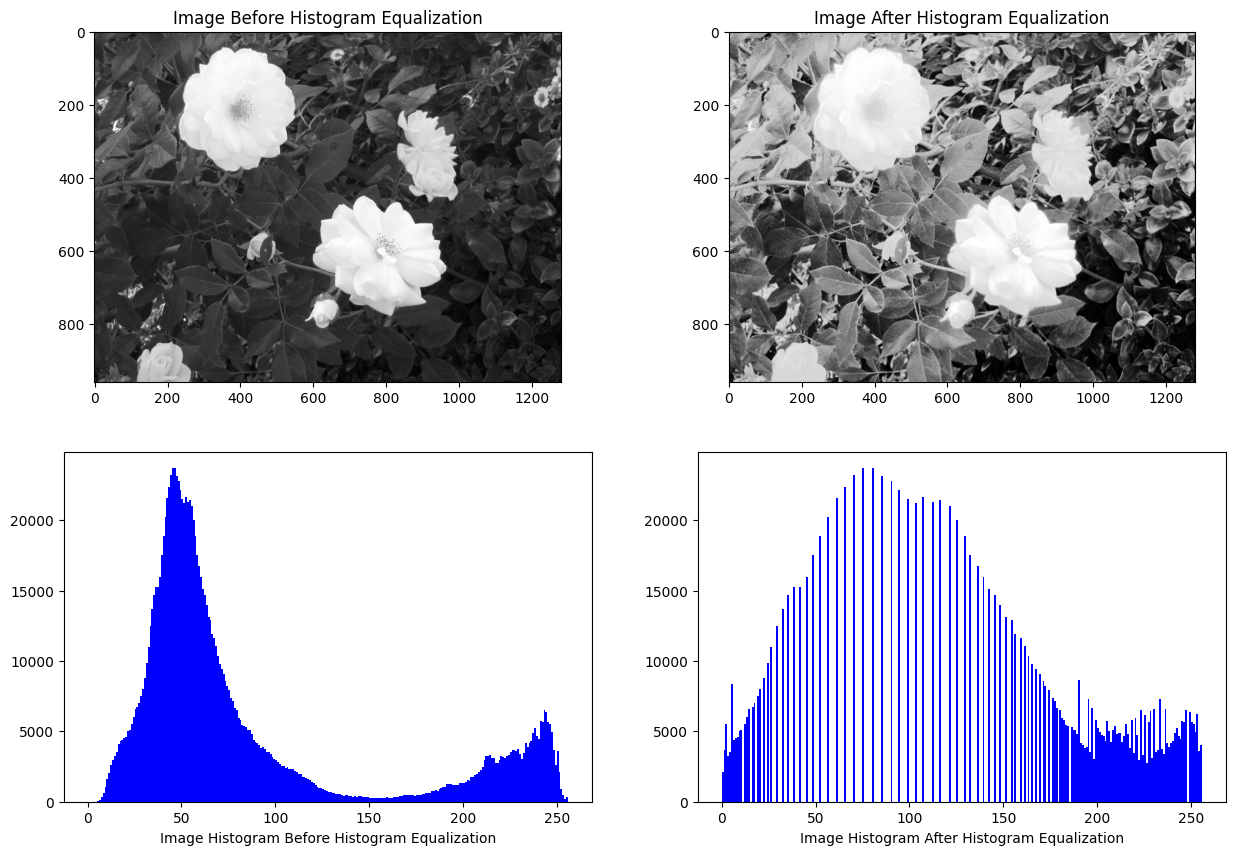

In [18]:
f, axes = plt.subplots(2, 2 , figsize=(15,10))
axes[0,0].imshow(img,cmap='gray')
axes[0,1].imshow(equ,cmap='gray')
axes[1,0].hist(img.flatten(),max_val,[min_val,max_val], color = 'blue')
axes[1,1].hist(equ.flatten(),max_val,[min_val,max_val], color = 'blue')
plt.setp(axes[0,0], title='Image Before Histogram Equalization')
plt.setp(axes[0,1], title='Image After Histogram Equalization')
plt.setp(axes[1,0], xlabel='Image Histogram Before Histogram Equalization')
plt.setp(axes[1,1], xlabel='Image Histogram After Histogram Equalization')
# f.tight_layout()
# plt.savefig('equalization.PNG')
plt.show()

Now you can see a more precise image with its pixels distributed form 0-255.

Suppose you are developing some computer vision applications in which leaf is a crucial element. You cannot deny the presence of leaves; then, you need leaves to be more precise.

As you can see, the equalization of the image made leaves more clear. This operation surely will help with your application.




## __When do Histogram Equalization fail?__

Equalization of the histogram is helpful when the image histogram is limited to a given area. In areas where there are broad differences in intensity, i.e., only both bright and dark pixels are present, it does not function well.

Let's see an example. Let's first create a binary image. In binary Image, there are broad differences in intensity value. Therefore histogram equalization makes no sense here.

__Example__

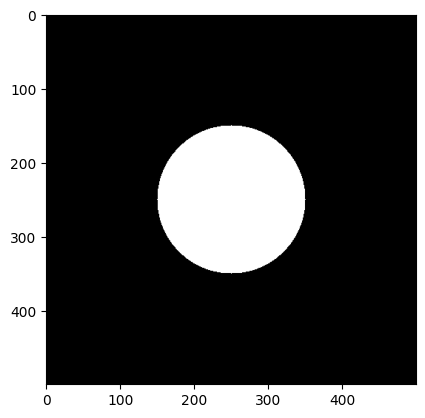

In [19]:
circle_image = np.zeros((500, 500), np.uint8) # zero is black
center_coordinates = (250, 250)
radius = 100
cv2.circle(circle_image, center_coordinates, radius, 255, -1) # 1 is white
plt.imshow(circle_image,cmap='gray')
plt.show()

__Plot Histogram.__

/tmp/ipykernel_16821/193525878.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(circle_image.ravel(),max_val,[min_val,max_val])


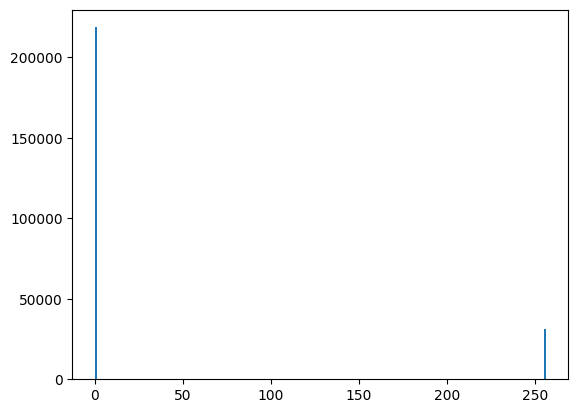

In [20]:
plt.hist(circle_image.ravel(),max_val,[min_val,max_val])
plt.show()

Image contains black and white pixels only. That's why bins of the histogram are concentrated on 0 and 255 on the X-axis.

In [21]:
equ_circle_image = cv2.equalizeHist(circle_image)

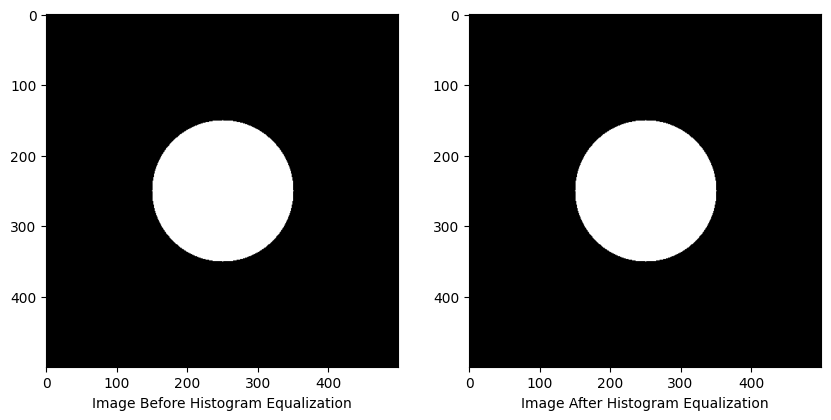

In [22]:
f, axes = plt.subplots(1, 2 , figsize=(10,8))
axes[0].imshow(circle_image,cmap='gray')
axes[1].imshow(equ_circle_image,cmap='gray')
plt.setp(axes[0], xlabel='Image Before Histogram Equalization')
plt.setp(axes[1], xlabel='Image After Histogram Equalization')
plt.show()

/tmp/ipykernel_16821/2380265013.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(circle_image.ravel(),max_val,[min_val,max_val])


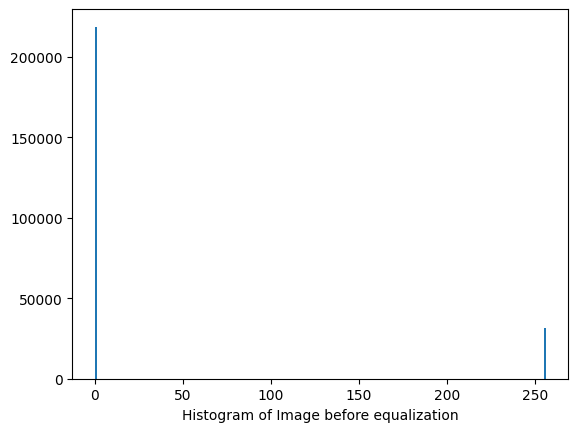

In [23]:
plt.hist(circle_image.ravel(),max_val,[min_val,max_val])
plt.xlabel("Histogram of Image before equalization")
# plt.savefig('hist_be_eq.png', dpi = 500)
plt.show()

/tmp/ipykernel_16821/3614411517.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equ_circle_image.ravel(),max_val,[min_val,max_val])


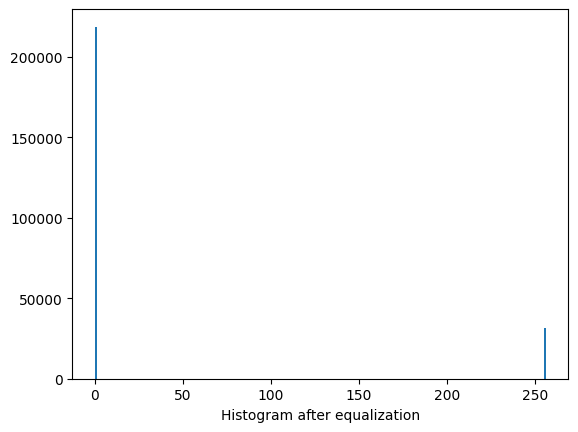

In [24]:
plt.hist(equ_circle_image.ravel(),max_val,[min_val,max_val])
plt.xlabel("Histogram after equalization")
# plt.savefig('hist_af_eq.png', dpi = 500)
plt.show()

After equalization, the output image is the same as the input image. There is no difference. Therefore histogram remains the same.

# Key Take-Aways

- The Image histogram gives pixel intensity distribution of an image.

- Different pictures may have different histograms.

- A single operation on the image may change its histogram.

- Histogram equalization is a method automatic contrast adjustment.


-  Equalization of the histogram is helpful when the image histogram is limited to a given area.

- In areas where there are broad differences in intensity where histogram covers a wide area, i.e., both bright and dark pixels are present, Equalization of histogram does not function well.